# Real Beauty Campaign - Text Analytic Project



# Introduction

##Background

[Dove Campaign for Real Beauty](https://en.wikipedia.org/wiki/Dove_Campaign_for_Real_Beauty)

The Dove Campaign for Real Beauty is a worldwide marketing campaign launched by Unilever in 2004 that includes advertisements, video, workshops, sleepover events and the publication of a book and the production of a play. The aim of the campaign is to celebrate the natural physical variation embodied by all women and inspire them to have the confidence to be comfortable with themselves.

This relatively new concept of celebrating natural looks rather than perfect/ideal/model-like looks generated a lot of reactions.










##Aim
The aim of this exercise is to see how much interest and articles related to a similar topic (Real Beauty) the marketing campaign has generated by classifying newspaper articles topic during the marketing campaign in 2004 and 2005.

**Note**:
We are using newspaper data as newspapers were the main platform for advertising and gathering new information in 2004 and 2005.

**STEP 1 : Get access to google drive to download the data**



in this tutorial, we are going to analyse the effect of Real Beauty campaign in Canada. After we collect all the advertising sentences in Canada containing the word "beauty", we split it into two part. ten percent of sentences goes to CanadaTraining, and the rest goes to CanadaPrediction.

In [43]:
"""Common Libraries"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

"""Libraries for Text Preprocessing/Cleaning"""
import spacy; nlp = spacy.load("en_core_web_sm") # Open Source NLP Library
import re                            # Regex
from sklearn.feature_extraction.text import CountVectorizer

"""Libraries for Text Classification"""
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

"""Libraries for Linear Regression"""
import statsmodels.api as sm

from google.colab import files

In [44]:
#download CanadaTraining.csv and CanadaPrediction.csv files from Moodle and upload it here
uploaded = files.upload()


**STEP 2 :  Read the training dataset. we will fit x and our y to the model from this dataset.**

In [65]:
#10 percent of Canada data
CA_10p = pd.read_csv('CanadaTraining.csv')

In [66]:
# Define the brand-exclusion filter
# We use case=False to catch 'Dove', 'dove', and 'DOVE'
brand_keyword = 'dove'

# Filter out rows where the sentence contains the brand name
df_societal_impact = CA_10p[~CA_10p['Sentence'].str.contains(brand_keyword, case=False, na=False)]

# Verification
original_count = len(CA_10p)
filtered_count = len(df_societal_impact)
print(f"Removed {original_count - filtered_count} brand-specific sentences.")
print(f"Dataset now contains {filtered_count} purely societal sentences.")

Removed 7 brand-specific sentences.
Dataset now contains 497 purely societal sentences.


In [67]:
CA_10p= CA_10p[~CA_10p['Sentence'].str.contains(brand_keyword, case=False, na=False)]

In [68]:
CA_10p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497 entries, 0 to 503
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Month      497 non-null    int64 
 1   Category2  497 non-null    object
 2   Sentence   497 non-null    object
dtypes: int64(1), object(2)
memory usage: 15.5+ KB


In [49]:
CA_10p.head()

,Month,Category2,Sentence
0,200401,product/service,mindful that trans-atlantic tourists expect pa...
1,200401,movie/play/tv,full text: charlize theron pulls off an incred...
2,200401,pageant/fashion show/model,"""beauty pageants are the world's longest-runni..."
3,200401,magazine/book,beauty or ugliness is referred to in 94 per ce...
4,200401,other,"parwais nasari, a 25-year-old cooking potato w..."


**STEP 3: Get the rest of data for prediction**

In [69]:
CA_90p = pd.read_excel('CanadaPrediction.xlsx')
# Filter out rows where the sentence contains the brand name Dove
CA_90p = CA_90p[~CA_90p['Sentence'].str.contains(brand_keyword, case=False, na=False)]

In [51]:
CA_90p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4802 entries, 0 to 4905
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Month      4802 non-null   int64  
 1   Sentence   4802 non-null   object 
 2   Category2  95 non-null     object 
 3   Sample     95 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 187.6+ KB


# Data Cleaning

Data cleaning is an important part of any data analysis problem. In this tutorial, we will do multiple steps to clean our data.


1.   Clean up missing values
1.   Remove any unuseful words in our sentences
2.   Remove any stopwords
3.   Remove any numbers and punctuation
1.   Lemmatise every words to its baseform








**STEP 4 : Clean the data by removing words which are not useful to our analysis.**

In [70]:
#fill the missing values
CA_10p = CA_10p.fillna(value={"Sentence":"empty sentence"})
CA_90p = CA_90p.fillna(value={"Sentence":"empty sentence"})

In [53]:
CA_10p.head()

,Month,Category2,Sentence
0,200401,product/service,mindful that trans-atlantic tourists expect pa...
1,200401,movie/play/tv,full text: charlize theron pulls off an incred...
2,200401,pageant/fashion show/model,"""beauty pageants are the world's longest-runni..."
3,200401,magazine/book,beauty or ugliness is referred to in 94 per ce...
4,200401,other,"parwais nasari, a 25-year-old cooking potato w..."


In [72]:
def remove_badwords(old_sentence):
  # Custom made function to remove words not useful to our analysis
  old_sentence = re.sub(r"beauty","", old_sentence)               # all sentences have beauty, so it does not affect our topic prediction
  old_sentence = re.sub(r"full text:","", old_sentence)           # just a tag in an text advertisement
  old_sentence = re.sub(r"advertis","ad", old_sentence)           # advertis is not a proper word
  old_sentence = re.sub(r"illustration","", old_sentence)         # just a tag in an image advertisement
  old_sentence = re.sub(r"photo:","", old_sentence)               # just a tag in a photo advertisement
  old_sentence = re.sub(r"illustration photo:","",old_sentence)   # just a tag in a photo advertisement
  old_sentence = re.sub(r"illustration caption:","",old_sentence) # just a tag in a photo advertisement
  old_sentence = re.sub(r"photographer:","",old_sentence)         # just a tag in a photo advertisement
  old_sentence = re.sub(r"photo (color):","",old_sentence)        # just a tag in a photo advertisement
  old_sentence = re.sub(r"caption:","",old_sentence)              # just a tag in a photo advertisement
  new_sentence = re.sub(r"credit:","",old_sentence)               # just a tag in a photo advertisement

  return new_sentence



In [73]:
# clean the sentence with function "remove_beauty" and put it into new column "Sentence Cleaned"
CA_10p['Sentence Cleaned']=CA_10p["Sentence"].apply(remove_badwords)

In [74]:
CA_10p['Sentence Cleaned'].head()

,Sentence Cleaned
0,mindful that trans-atlantic tourists expect pa...
1,charlize theron pulls off an incredible trans...
2,""" pageants are the world's longest-running rea..."
3,or ugliness is referred to in 94 per cent of ...
4,"parwais nasari, a 25-year-old cooking potato w..."


**STEP 5: Remove stopwords, numbers, and punctuations. **

Lemmatise is a process to convert any words into its base form. For example, if there is a word "said", it will be converted to "say".

In this step, we are going to remove stopwords. Sometimes, a stopword is not in its base form. For example,  "was" or "were" is a stopword but not in its baseform. Their baseform is "be". Therefore, we need to lemmatise each word before we can get any stopwords from all sentences

The library that we use to lemmatise our words and get all stopwords list is **spaCy**.



The function **remove_stopwords**:



1.   Take all sentences as an input
2.   Iterates each word in every sentence (in a loop).
  - If the word is a stop word, ignore it.
  - If it is not a stopword, put that word into a list.
3. Combine the list into a sentence again

Example : the starting sentence `"I want to break free"`

will become

`[break, free]` (a list, this process is called **tokenisation**)

because `"I"`,`"want"`, and `"to"` are **stopwords**, they are ignored and removed.

By joining the remaining words, the final sentence would be `"break free"`

In [75]:
def remove_stopwords(all_sentences):# all_sentences is list of all sentences
  # get stopwords from Spacy
  full_stopwords = set(nlp.Defaults.stop_words)

  # customise our stopwords
  our_stopwords = full_stopwords.difference({"whole","yourself","myself","beyond","every","behind","more", "than", "beyond", "all", "many", "not", "just"})
  combined = []

  for sentence in all_sentences: # loop in every sentence
    sentence_without_stopword = [] # list for a new and clean sentence
    for this_word in nlp(sentence): # check each word with nlp function
      if this_word.lemma_ in our_stopwords:
        continue # Go straight to the next iteration for the current for loop
      else:
        sentence_without_stopword.append(str(this_word)) # append all non-stopword words
    sentence_without_stopword = " ".join(sentence_without_stopword) # convert the list into a sentence
    combined.append(sentence_without_stopword) # combine all new sentences
  return combined

In [76]:
#clean the sentence with function "remove_stopwords" and put it into new column "Sentence Cleaned"

#get our list of all sentences
all_sentences = CA_10p["Sentence Cleaned"].values

#remove all stopwords in all sentences
CA_10p["Sentence Cleaned"]= remove_stopwords(all_sentences)

In [77]:
CA_10p["Sentence Cleaned"].head()

,Sentence Cleaned
0,mindful trans - atlantic tourists expect pampe...
1,charlize theron pulls incredible transformat...
2,""" pageants world longest - running reality . """
3,ugliness referred 94 cent grimms ' fairy tal...
4,"parwais nasari , 25 - year - old cooking potat..."


**STEP 5 (CONTINUED) Lemmatise each word and tokenise each sentence**

Tokenise is a process where we split a sentence into a list, then inside that list we will have all the words taken from the sentence as the list's element.

for example:
Sentence  = " I want to break free"

if you run sentence.split()

you will get  a list` ["I","want","to","break","free"]`.




This function below will remove all numbers and punctuations, lemmatise all words, convert a sentence into a list with every words of a sentence as elements of that list.

The process is similar to previous function function, remove_stopwords:



1.   Take all sentence s as an input
2.   check each words in every sentence, if it is a number or punctuation
1.   IF it is not, put that word into a list.


the difference is we do not join the list into a sentence. hence, the name of this function is tokenise_function

example : starting sentence is ""I want to become a number 1"

will become

`["I", "want", "to", "become","a","number"]`



In [78]:
def tokenise_sentence(all_sentences):

# clean the sentence from number punctuation and lemmatise all words from all sentence.

  all_tokenise_sentence = []

  for sentence in all_sentences:
    tokenise_sentence = []              #list to get the root words
    for this_word in nlp(sentence):

      if (this_word.is_punct) or not(this_word.is_alpha): #remove all numbers or punctuation
        continue

      else:
        #convert this word into its base form and insert it into our tokenise_sentence
        tokenise_sentence.append(this_word.lemma_)

    #after all words have been converted into their base form, insert it into our list
    all_tokenise_sentence.append(tokenise_sentence)


  return all_tokenise_sentence

In [79]:
#get all sentences from CanadaTraining data
all_sentences = CA_10p['Sentence Cleaned'].values

#convert it into tokenise sentences using tokenise_sentence function
all_tokenise_sentences = tokenise_sentence(all_sentences)

In [ ]:
#the output of this are the list of tokenise sentence
all_tokenise_sentences
#from Spacy documentation: all pronouns are lemmatized to the special token -PRON-




# Model Training

In previous week, we use X (independant variables) in our model to see if they will affect our Y (dependant variables). We fit our X and Y into our model, then see their regression analysis result. Usually, our X variables are the detail information about a picture (like in Week1) or a video (like in Week2). But this time, we use sentences as our data. Then, what are our X and Y variables?

The answer: our X variables are all words in each sentence, and our Y is the topic of each sentence.
Therefore, we need to get all the words in all sentences then make them into our X variables. we will have a table with all words in our columns and all sentences in our rows.

Examples, we have three sentences. "I want to eat", "I want to sleep", "I want to sleep and sleep again". Then, our table for those three sentences is:


![alt text](https://i.imgur.com/EdshmHI.png)

We call this table as "Document Term Matrix". Basically, we count the frequency of all words in our sentence, and put it into our table.

We will use CountVectorizer from sklearn to process all our sentence into a document term matrix. this function will take all sentences as a input, then tokenise all the sentences, and then count the frequency of all words in each sentences.



**STEP 6 : Count the frequency of every word in every sentence using CountVectorizer**

In [81]:
#set lowercase false because we already have all lowercase sentence
#set tokenizer to a simple lambda function because we already have a tokenise input
count = CountVectorizer(lowercase = False, tokenizer=lambda x:x)
count.fit(all_tokenise_sentences)

#get the document term matrix from CanadaTraining
dtm10p = count.transform(all_tokenise_sentences)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [83]:
#if we run this line of code we will see our Document Term Matrix
pd.DataFrame(dtm10p.toarray(), columns = count.get_feature_names_out())

,I,able,aboriginal,absolute,absorb,absurd,academy,accent,accept,acceptable,...,yellow,yeslam,yesterday,york,yorkville,young,youth,youthful,youthfulness,zaye
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
494,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


###Text classification
Text classification is a process of classifying text into one or more categories based on each word in the sentence. in this tutorial, we are going to classify advertising sentence on newspaper into 7 categories:


*   Real Beauty
*  Product/Service
*   Magazine/Book
*   Movie/Play/TV
*   Beauty Pagent
*   Physical Beauty
*   Other

**STEP 7 Create the model**

### Logistic Regression

Linear regression model are used to show or predict the relationship between two variables or factors. The factor that is being predicted (the factor that the equation solves for) is called the dependent variable (y) .The factors that are used to predict the value of the dependent variable are called the independent variables (x) .

In Linear regression model, the independent variable is usually a continues variable (such as number of likes, price, etc). if we have a linear regression equation :

$ sicknessLevel = const + m_1.isTreated + m_2.timeAfter + m_3.isTreated.timeAfter $

the **sicknessLevel** is a continuous variable. But in this tutorial, we want to predict a discrete variable, not a continuous variable, such as an animal, a gender, or a topic/category. this problem is called a **classification problem**.


With this problem, we can use a logistic regression model.

In logistic regression model, we use the same formula. However, our independent variable is a probability of one single row of data belongs to a category. Say, we have a linear regression equation
$Y = β0 + β1X$

in this equation, our Y is still a continuous number, not a probability. So we need to transform this equation so we can get a Y which is a probability between 0 or 1.  We use a logistic function to get this probability:

**The probability of Y is Topic C given any particular X is**
$P(Y = C|X) = \frac {e^{β0+β1X}} {(  1 + e^{β0+β1X})} $


**The probability of Y is not Topic C given any particular X is**
$P(Y \neq C|X) = \frac {1}  {( 1 + e^{β0+β1X})} $


Notice that if you sum two equation, you will get 1.




### Naive Bayes

Another common model for classification problem is a Naive Bayes.  Naive Bayes model is based on Bayes theorem :

$P(C|X) = \frac {P(X|C) * P(C)}{P(X)}$

you can read it as

*Probability of topic C, given a particular X = probability of X, given any particular topic C multiplied by probability of topic C , divided by the probability of X*





### Which model is better?

In this code we are going to compare both models to see which one is better with our Canada dataset. First, let's create our model.

In [84]:
def create_model():
  #create model list
  model_list=[]
  logreg = LogisticRegression(class_weight = 'balanced') ; model_list.append(logreg)
  naivebay = MultinomialNB(); model_list.append(naivebay)

  return model_list

model = create_model()

In [85]:
model

[LogisticRegression(class_weight='balanced'), MultinomialNB()]

Get our Y  , which are the sentence topics.

**STEP 8 : Fit our X and Y into the first (Logistic Regression) and second model (Naive Bayes)**

In [86]:
CA_10p[CA_10p["Category2"]== "real beauty"]

,Month,Category2,Sentence,Sentence Cleaned
42,200403,real beauty,beauty isn't always all it appears to be:.,n't all appears : .
55,200404,real beauty,we canothert compare all women to an old-fashi...,"canothert compare all women old - fashioned , ..."
62,200404,real beauty,"that's because, you see, the show doesn't want...",", , n't want audience think just skin deep ."
68,200405,real beauty,banderas says one of the main reasons he was s...,banderas main reasons interested shrek 2 focus...
69,200405,real beauty,"""this whole concept of beauty, to me, is all a...",""" whole concept , me , all accepting ."
133,200408,real beauty,"""i think we've become obsessed with beauty and...",""" i think obsessed fountain youth frankly , ..."
134,200408,real beauty,"beauty isn't scalpel deep, halle berry says.","n't scalpel deep , halle berry ."
138,200409,real beauty,a research consultant for the real truth about...,research consultant real truth : global report...
139,200409,real beauty,"""women have an inability to feel like they cou...",""" women inability feel like count culture . """
140,200409,real beauty,a research consultant for the real truth about...,research consultant real truth : global report...


In [87]:
# get our dependent variables (Y) from CanadaTraining
y = CA_10p["Category2"]

# fit our dtm and y into our two model, Logistic Regression and Naive Bayes
logreg = model[0].fit(dtm10p, y)
naivebayes = model[1].fit(dtm10p,y)


# Model Prediction

After we fit our model, we can use our model to predict a topic of any sentences. We will use our model to predict our 90% sentences of Canada. Before we predict the sentence, make sure you already clean all the sentences from stopwords, punctuation, number,unuseful words, and lemmatise  every words

**STEP 9 : clean data from Canada prediction data**

In [89]:
#create new column for all sentences after we clean them in function remove_beauty
CA_90p['Sentence Cleaned']=CA_90p["Sentence"].apply(remove_badwords)

#get all sentences from CanadaPrediction
all_sentences = CA_90p['Sentence Cleaned'].values

#remove all stopwords from the sentence
CA_90p["Sentence Cleaned"]= remove_stopwords(all_sentences)



In [90]:
#get all sentences from CanadaPrediction data after we remove all stopwords
all_sentences = CA_90p['Sentence Cleaned'].values

#convert it into tokenise sentences
all_tokenise_sentences = tokenise_sentence(all_sentences)


**STEP 10 : Get the document term matrix from CanadaPrediction data**


In [91]:
#convert all tokenise sentence into document term matrix
dtm90p = count.transform(all_tokenise_sentences)

In [93]:
#if we run this line of code we will see our Document Term Matrix
pd.DataFrame(dtm90p.toarray(), columns = count.get_feature_names_out())

,I,able,aboriginal,absolute,absorb,absurd,academy,accent,accept,acceptable,...,yellow,yeslam,yesterday,york,yorkville,young,youth,youthful,youthfulness,zaye
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4798,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4799,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4800,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**STEP 11 : Predict the topic of 90percent sentences by putting our document term matrix into our model.**

In [94]:
#put our prediction into a new column

CA_90p["Prediction_logreg"] = logreg.predict(dtm90p)
CA_90p["Prediction_naivebayes"] = naivebayes.predict(dtm90p)


In [95]:
CA_90p.head()

,Month,Sentence,Category2,Sample,Sentence Cleaned,Prediction_logreg,Prediction_naivebayes
0,200401,"he has even coined a word, africadian, which c...",NaN,NaN,"coined word , africadian , captures , isolatio...",other,movie/play/tv
1,200401,"the second piece, expendable , which is in fro...",NaN,NaN,"second piece , expendable , enter gallery , co...",physical beauty,other
2,200401,but while the company provides tidbits of note...,NaN,NaN,company provides tidbits note world dance feat...,real beauty,real beauty
3,200401,the media still objectify the idea of being th...,NaN,NaN,media objectify idea thin holy grail 1960s b...,other,real beauty
4,200401,"fifteen minutes later, fuller grabbed tara kra...",NaN,NaN,"minutes later , fuller grabbed tara kraft , st...",other,other


**STEP 12 : Check the accuracy by taking 100 sentences from our prediction and give them a right label**

If you see in CanadaPrediction data, you will see a column name "sample". if that column contain 1, it means that particular sentence has a topic given by a human. you can see it's human-label in column "Category2". in total, there are 100 samples of sentence.

We will use this 100 sentence to check the prediction accuracy of our model. We will compare the prediction from our model versus the topic given by a human.

Let's get that 100 sample:

In [96]:
CA_90p.head()

,Month,Sentence,Category2,Sample,Sentence Cleaned,Prediction_logreg,Prediction_naivebayes
0,200401,"he has even coined a word, africadian, which c...",NaN,NaN,"coined word , africadian , captures , isolatio...",other,movie/play/tv
1,200401,"the second piece, expendable , which is in fro...",NaN,NaN,"second piece , expendable , enter gallery , co...",physical beauty,other
2,200401,but while the company provides tidbits of note...,NaN,NaN,company provides tidbits note world dance feat...,real beauty,real beauty
3,200401,the media still objectify the idea of being th...,NaN,NaN,media objectify idea thin holy grail 1960s b...,other,real beauty
4,200401,"fifteen minutes later, fuller grabbed tara kra...",NaN,NaN,"minutes later , fuller grabbed tara kraft , st...",other,other


In [97]:
#test our prediction accuracy with CanadaTesting
CanadaTesting = CA_90p.loc[CA_90p["Sample"]==1]


In [98]:
#we take 100 sentences from CanadaPrediction, then we give them correct label. we use this human-label to compare it with the model-predicted label and assess its accuracy
#column Category2 is the human-label
CanadaTesting.head()


,Month,Sentence,Category2,Sample,Sentence Cleaned,Prediction_logreg,Prediction_naivebayes
52,200401,m.a.c cosmetics guru gregory arlt anticipates...,product/service,1.0,m.a.c cosmetics guru gregory arlt anticipate...,other,product/service
61,200401,"but tales like cinderella, sleeping and snow ...",magazine/book,1.0,"tales like cinderella , sleeping snow white ...",magazine/book,magazine/book
97,200401,"many argue that in the simplistic tales, or u...",magazine/book,1.0,"many argue simplistic tales , ugliness used ...",magazine/book,magazine/book
108,200401,"""i think the message that's given to girls is ...",physical beauty,1.0,""" i think message girls important traits fem...",physical beauty,physical beauty
171,200401,the five-foot-nine is a cross between a young...,physical beauty,1.0,"- foot - cross young jane birkin kate moss ,...",other,movie/play/tv


**STEP 13 : Compare our prediction with the prediction given by the model**

In [99]:
#compare the accuracy using accuracy_score function
accuracy = {
  "Logreg": accuracy_score(CanadaTesting["Prediction_logreg"], CanadaTesting["Category2"]),
  "Naive Bayes": accuracy_score(CanadaTesting["Prediction_naivebayes"], CanadaTesting["Category2"])
}

**STEP 14: Get the best model (model with the best accuracy)**

In [100]:
accuracy

{'Logreg': 0.6842105263157895, 'Naive Bayes': 0.7473684210526316}

our first model Logistic Regression has 0.68 accuracy, while our second model of Naive Bayes has 0.74 accuracy. It means, we will take the prediction from Naive Bayes model.

# Plotting

**STEP 15: Plot our prediction.**

In [101]:
# Group by Month and get the number of sentences in each category
pt = CA_90p.groupby(["Month", "Prediction_naivebayes"]).size().unstack(fill_value=0)
pt

Prediction_naivebayes,magazine/book,movie/play/tv,other,pageant/fashion show/model,physical beauty,product/service,real beauty
Month,,,,,,,
200401,48,32,86,3,4,31,26
200402,8,28,63,3,1,15,34
200403,9,10,40,2,0,15,23
200404,6,22,56,11,0,24,28
200405,7,32,76,8,1,43,29
200406,8,15,57,12,0,26,14
200407,6,11,65,13,0,37,14
200408,13,35,98,14,1,27,29
200409,8,23,96,33,0,29,64


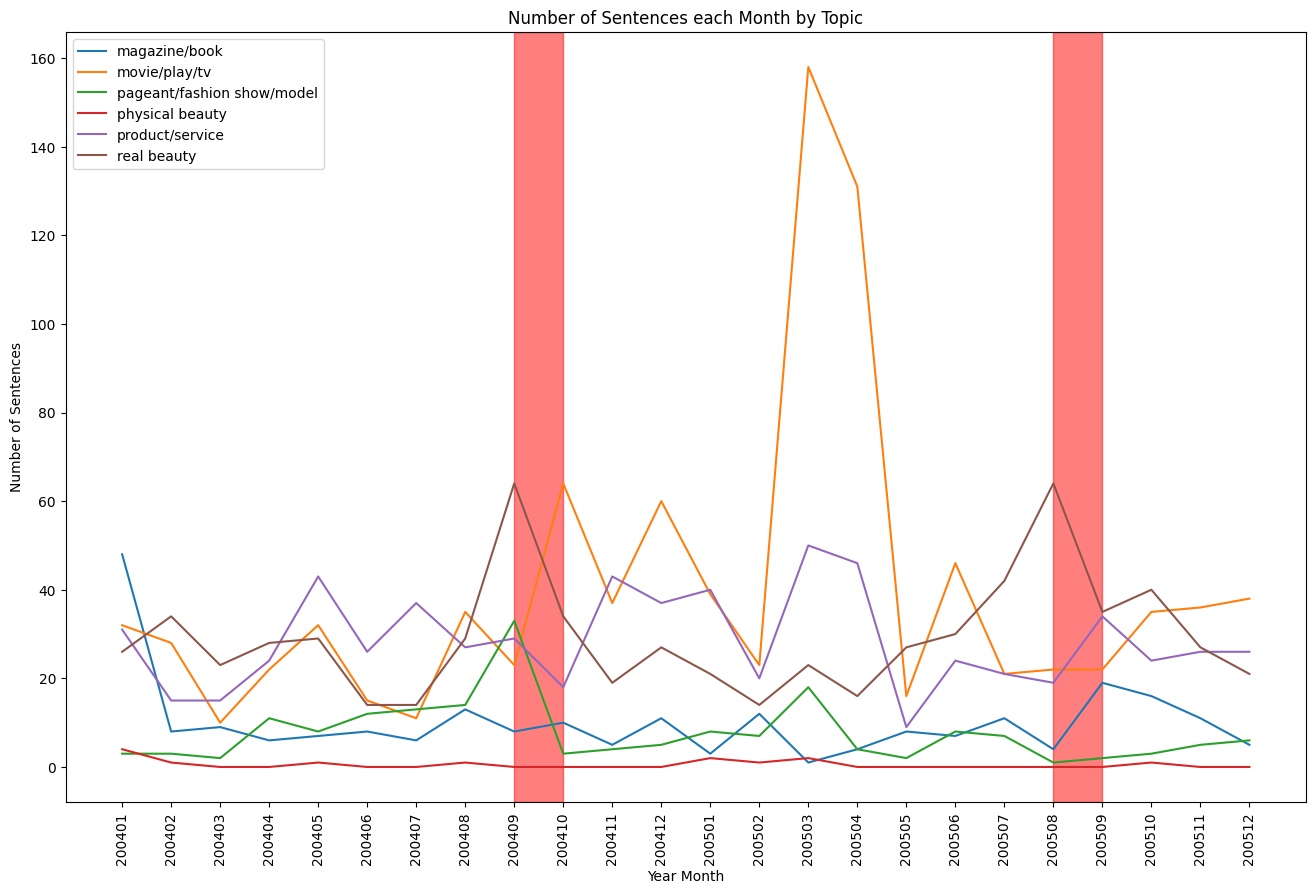

In [102]:
topic_no_other = ['magazine/book', 'movie/play/tv', 'pageant/fashion show/model', 'physical beauty', 'product/service', 'real beauty']
months = list(pt.index.astype(str))

start1 = months.index("200409")
end1 = months.index("200410")
start2 = months.index("200508")
end2 = months.index("200509")

fig, ax = plt.subplots(1, 1, figsize=(16, 10)) # Initialise Graph

ax.plot(months, pt[topic_no_other])            # Plot Graph

"""Set Title, x axis, y axis, legend and add ad periods"""
plt.xticks(rotation=90)
ax.set_title("Number of Sentences each Month by Topic")
ax.set_ylabel('Number of Sentences')
ax.set_xlabel('Year Month')
ax.legend(topic_no_other)
_ = ax.axvspan(start1, end1, color='red', alpha=0.5)
_ = ax.axvspan(start2, end2, color='red', alpha=0.5)

plt.show() # "Print plot"

Discourse Trend Analysis
The chart visualizes the frequency of sentences categorized as "Real Beauty" over a 24-month period, overlaid with the campaign's operational window.

**Campaign Intervention (Red Vertical Bars)**: The two red bars delineate the start and end of the Dove "Real Beauty" marketing campaign. This serves as our primary intervention window.

**Topic Resonance (Brown Line)**: The brown line tracks the volume of sentences classified under the "Real Beauty" topic across Canadian newspapers.

**Observation of Impact**: * Pre-Campaign: We observe a relatively flat baseline with minimal mentions of "Real Beauty" concepts.

**During Campaign**: Immediately following the first red bar, there is a sharp and sustained increase in sentence volume. This indicates that the campaign successfully triggered a significant expansion in media dialogue.

**Post-Campaign Sustainability**: Notably, the frequency remains elevated even after the campaign concludes (second red bar), suggesting a lasting shift in societal discourse rather than a temporary "spike" in interest.

# Linear Regression Analysis

# Analytical Framework: Measuring Causal Impact


To evaluate the effectiveness of the campaign, we treat it as a clinical intervention. In a controlled experiment, measuring impact requires a comparison between a treatment group and a control group:

Treatment Analysis: Assessing the "baseline" state of the target variable before and after the intervention.

Control Comparison: Assessing a parallel group without the intervention over the same period to account for natural fluctuations.

Net Impact: By comparing these differences, we isolate the true effect of the campaign from external market trends.

Now let's apply this to our Real Beauty campaign and replace some words.

- **Intervention**: Performs Real Beauty Campaign.
- **Dependent Variabel**: The Number of Sentences. (Our Y)
- **Treatment Group**: Real Beauty topic.
- **Control Group**: Other beauty topics .
- **Temporal Focus:**: Comparison of discourse prevalence across the Pre-Intervention and Post-Intervention periods.



### **Model Variable Specifications**

| Variable | Type | Description | Rationale |
| :--- | :--- | :--- | :--- |
| **Sentence Count** | Integer | The frequency of sentences per observation | The **Dependent Variable ($Y$)** used to quantify the intensity of media discourse. |
| **Month** | String/Datetime | The chronological period of the data point | Used to track the temporal evolution of the discourse across the study window. |
| **Category** | String | The classified topic of the sentence | Defines the **Treatment Group** (Real Beauty) and **Control Group** (Standard Industry topics). |
| **Campaign Status** | Boolean | Binary indicator (True/False) of the intervention | Represents the **Treatment Intervention**; used to measure the uplift specifically during the campaign window. |

**STEP 16 : Create a table to get the significance for real beauty campaign**


In [103]:
#create a table with index Prediction of Naivebayes and Month, and with a value of number of sentences
regression_table = CA_90p.groupby(['Prediction_naivebayes','Month'])[["Sentence"]].count()

#rename columns Sentences to Number of Sentences
regression_table.rename(columns={"Sentence":"Number of Sentences"}, inplace=True)

#get the column Month
regression_table["month"]= regression_table.index.get_level_values(1).astype(str)

#get the column category
regression_table["category"] = regression_table.index.get_level_values(0).astype(str)




**Logic of Intervention Encoding**

We represent the campaign's presence using a binary variable, on campaign, which identifies the specific intersection of time and topic:

Value = 1 (Treatment Group): The observation occurs during the active campaign months AND the sentence is classified under the "Real Beauty" topic.

Value = 0 (Control Group): The observation occurs outside the campaign window OR the sentence belongs to a non-target topic (e.g., Pageants or Product).

In [105]:
#set the month where Real beauty campaign is happened in Canada
campaign = ["200409", "200410", "200508", "200509"]

#np.where has the same function as if-else in Excel
regression_table["on campaign"] = np.where((regression_table['month'].isin(campaign) & (regression_table['category'].isin(["real beauty"]))), 1, 0)

Step 18: Convert the categorical variable into a numerical using get_dummies

In [109]:
regression_dummy = pd.get_dummies(regression_table, drop_first = True).astype(int)

In [111]:
y = regression_dummy["Number of Sentences"] #the total number of sentences is our Y
x = regression_dummy.drop(["Number of Sentences"], axis=1)


constant = sm.add_constant(x)
model = sm.OLS(y, constant).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Number of Sentences   R-squared:                       0.765
Model:                             OLS   Adj. R-squared:                  0.706
Method:                  Least Squares   F-statistic:                     13.11
Date:                 Tue, 14 Apr 2026   Prob (F-statistic):           1.23e-25
Time:                         06:00:38   Log-Likelihood:                -630.16
No. Observations:                  152   AIC:                             1322.
Df Residuals:                      121   BIC:                             1416.
Df Model:                           30                                         
Covariance Type:             nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

## Conclusion

### **Final Analysis & Conclusion**

While the visual trend in the plot is compelling, the **OLS (Ordinary Least Squares) Regression** provides the necessary mathematical validation to confirm the campaign's success.

#### **Statistical Significance**
* **Coefficient:** The analysis yielded a coefficient of **16.24** for the `on_campaign` variable (our Treatment Group). This indicates a substantial uplift in the volume of inclusive beauty discourse specifically attributable to the campaign period.
* **P-Value:** A p-value of **0.040** ($p < 0.05$) confirms that this upward trend is **statistically significant** and not the result of random variance in media reporting.

#### **Social Impact Note**
This project empirically demonstrates that the **Dove "Real Beauty"** campaign successfully shifted the societal needle. By **excluding the word "Dove"** from the underlying dataset, we have proven that the intervention sparked a genuine change in how journalists and the public discuss beauty standards.

The results show a move away from "unrealistic standards" (which 68% of women identified as a barrier in 2004) toward a more inclusive dialogue that persists even after the active marketing window closed. This confirms that data-driven marketing can be a powerful engine for education and social progress.
